In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 4, "cos": 4}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


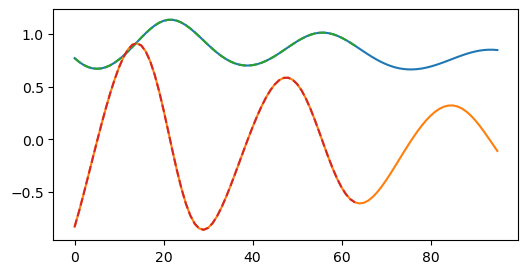

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.back_nsample + args.fore_nsample]
        back = replay[:, offset:offset + args.back_nsample]

        true, _ = dataset.normalizer.normalize(true)
        back, _ = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        #plt.plot(true_n[jdata, :, :2])
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.152137, valid=1.002231, test=0.904212
	validation loss decreased (inf -> 1.002231), saving model ...
	epoch 2 losses: train=1.117595, valid=0.972376, test=0.893383
	validation loss decreased (1.002231 -> 0.972376), saving model ...
	epoch 3 losses: train=1.075983, valid=0.960343, test=0.886261
	validation loss decreased (0.972376 -> 0.960343), saving model ...
	epoch 4 losses: train=1.062614, valid=0.952777, test=0.883230
	validation loss decreased (0.960343 -> 0.952777), saving model ...
	epoch 5 losses: train=1.051777, valid=0.938497, test=0.878220
	validation loss decreased (0.952777 -> 0.938497), saving model ...
	epoch 6 losses: train=1.035176, valid=0.920785, test=0.872690
	validation loss decreased (0.938497 -> 0.920785), saving model ...
	epoch 7 losses: train=1.015831, valid=0.902295, test=0.868268
	validation loss decreased (0.920785 -> 0.902295), saving model ...
	epoch 8 losses: train=0.996031, valid=0.883072, test=0.86

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

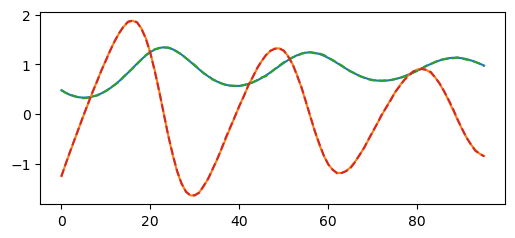

In [8]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

#print(tata.shape)

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.881710, valid=1.349299, test=0.872455
	validation loss decreased (inf -> 1.349299), saving model ...
	epoch 2 losses: train=0.855883, valid=1.331917, test=0.863484
	validation loss decreased (1.349299 -> 1.331917), saving model ...
	epoch 3 losses: train=0.843883, valid=1.320254, test=0.857201
	validation loss decreased (1.331917 -> 1.320254), saving model ...
	epoch 4 losses: train=0.835854, valid=1.309020, test=0.852665
	validation loss decreased (1.320254 -> 1.309020), saving model ...
	epoch 5 losses: train=0.828899, valid=1.295901, test=0.846691
	validation loss decreased (1.309020 -> 1.295901), saving model ...
	epoch 6 losses: train=0.820622, valid=1.282674, test=0.839737
	validation loss decreased (1.295901 -> 1.282674), saving model ...
	epoch 7 losses: train=0.811851, valid=1.268494, test=0.832825
	validation loss decreased (1.282674 -> 1.268494), saving model ...
	epoch 8 losses: train=0.802831, valid=1.251851, te

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

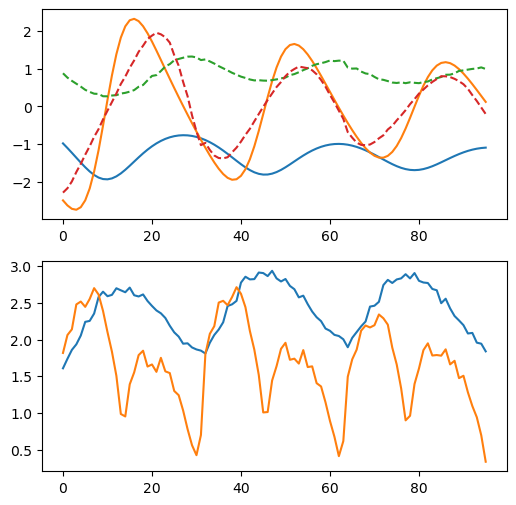

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.953482, valid=1.051740, test=0.915309
	validation loss decreased (inf -> 1.051740), saving model ...
	epoch 2 losses: train=0.910910, valid=1.000075, test=0.916195
	validation loss decreased (1.051740 -> 1.000075), saving model ...
	epoch 3 losses: train=0.843276, valid=0.872548, test=0.850732
	validation loss decreased (1.000075 -> 0.872548), saving model ...
	epoch 4 losses: train=0.727070, valid=0.758744, test=0.754085
	validation loss decreased (0.872548 -> 0.758744), saving model ...
	epoch 5 losses: train=0.627207, valid=0.694458, test=0.697567
	validation loss decreased (0.758744 -> 0.694458), saving model ...
	epoch 6 losses: train=0.540571, valid=0.632474, test=0.607835
	validation loss decreased (0.694458 -> 0.632474), saving model ...
	epoch 7 losses: train=0.513715, valid=0.591488, test=0.560796
	validation loss decreased (0.632474 -> 0.591488), saving model ...
	epoch 8 losses: train=0.474886, valid=0.584369, test=0.

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

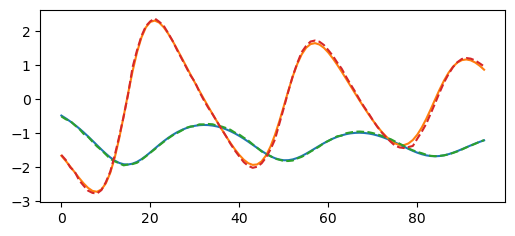

In [14]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.100136, valid=0.134564, test=0.087038
	validation loss decreased (inf -> 0.134564), saving model ...
	epoch 2 losses: train=0.068601, valid=0.126814, test=0.080114
	validation loss decreased (0.134564 -> 0.126814), saving model ...
	epoch 3 losses: train=0.057811, valid=0.125323, test=0.078301
	validation loss decreased (0.126814 -> 0.125323), saving model ...
	epoch 4 losses: train=0.060787, valid=0.123622, test=0.075484
	validation loss decreased (0.125323 -> 0.123622), saving model ...
	epoch 5 losses: train=0.058278, valid=0.121403, test=0.072639
	validation loss decreased (0.123622 -> 0.121403), saving model ...
	epoch 6 losses: train=0.059679, valid=0.119604, test=0.070556
	validation loss decreased (0.121403 -> 0.119604), saving model ...
	epoch 7 losses: train=0.052015, valid=0.118381, test=0.069203
	validation loss decreased (0.119604 -> 0.118381), saving model ...
	epoch 8 losses: train=0.051439, valid=0.117566, 

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

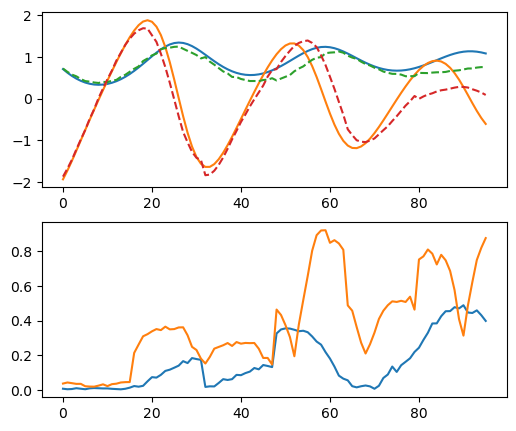

In [17]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

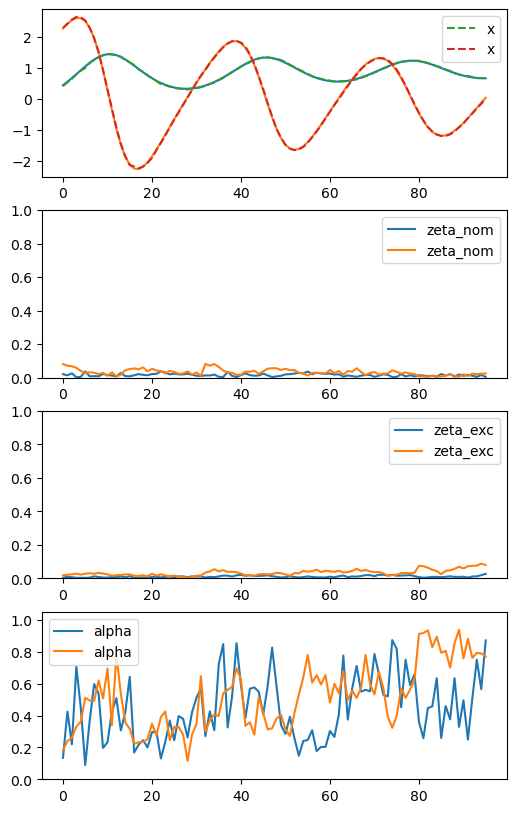

In [18]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break